In [5]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import cv2


## 遗传算法

In [ ]:
class GA:  # 定义遗传算法类
    def __init__(self, image, M):  # 构造函数,进行初始化以及编码
        self.image = image
        self.M = M  # 初始化种群的个体数
        self.length = 8  # 每条染色体基因长度为8(0-255)
        self.species = np.random.randint(0, 256, self.M)  # 给种群随机编码
        self.select_rate = 0.5  # 选择的概率
        self.strong_rate = 0.3  # 选择适应性强染色体的比率
        self.bianyi_rate = 0.05  # 变异的概率

    def Adaptation(self, ranseti):  # 进行染色体适应度的评估
        fit = OTSU().otsu(self.image, ranseti)
        return fit

    def selection(self):  # 进行个体的选择
        fitness = []
        for ranseti in self.species:  # 循环遍历种群，计算适应度
            fitness.append((self.Adaptation(ranseti), ranseti))
            # 元素：（适应度值，染色体值）
        
        # 逆序排序，适应度高的染色体排前面
        fitness1 = sorted(fitness, key=lambda x: x[0], reverse=True)
        
        # 提取排序后的染色体
        sorted_species = [x[1] for x in fitness1]
        
        # 适应性特别强的直接留下来
        num_strong = int(len(sorted_species) * self.strong_rate)
        parents = sorted_species[:num_strong]
        
        # 轮盘赌机制选择其他染色体
        for ranseti in sorted_species[num_strong:]:
            if np.random.random() < self.select_rate:
                parents.append(ranseti)
        return parents

    def crossover(self, parents):  # 进行个体的交叉
        children = []
        child_count = len(self.species) - len(parents)  # 补足种群数量（或者说产生新个体）
        
        while len(children) < child_count:
            father_idx = np.random.randint(0, len(parents))
            mather_idx = np.random.randint(0, len(parents))
            
            if father_idx != mather_idx:
                father = parents[father_idx]
                mather = parents[mather_idx]
                
                position = np.random.randint(0, self.length)  # 随机选取交叉位置
                mask = 0
                for i in range(position):  # 11110000
                    mask = mask | (1 << i)
                
                child = (father & mask) | (mather & ~mask)
                children.append(child)
        
        self.species = parents + children  # 更新种群

    def bianyi(self):  # 进行个体的变异（变异策略可以自己调整，细微影响收敛的快慢）
        for i in range(len(self.species)):
            if np.random.random() < self.bianyi_rate:
                j = np.random.randint(0, self.length)
                self.species[i] = self.species[i] ^ (1 << j)  # 亦或加移位

    def evolution(self):  # 进行个体的进化
        parents = self.selection()
        self.crossover(parents)
        self.bianyi()

    def get_threshold(self):  # 返回适应度最高的染色体
        fitness = []
        for ranseti in self.species:
            fitness.append((self.Adaptation(ranseti), ranseti))
        # 返回适应度最高的那个染色体的值
        return max(fitness, key=lambda x: x[0])[1]

## 大津算法

In [3]:
class OTSU:  # 定义大津算法类
    def otsu(self, image, threshold):  # 计算适应度 (类间方差)
        # 扁平化处理方便计算，虽然不扁平化也可以，但在做mask时扁平化逻辑更直观
        img_flat = image.ravel() 
        size = img_flat.size
        
        bin_image_mask = img_flat < threshold
        
        w0 = np.sum(bin_image_mask) # 前景像素数
        w1 = size - w0             # 背景像素数
        
        # 避免分母为0的情况
        if w0 == 0 or w1 == 0:
            return 0
        
        # 计算像素值总和
        sum_all = np.sum(img_flat)
        sum0 = np.sum(img_flat[bin_image_mask])
        sum1 = sum_all - sum0
        
        mean0 = sum0 / w0
        mean1 = sum1 / w1
        
        # 类间方差公式
        fitt = (w0 / size) * (w1 / size) * ((mean0 - mean1) ** 2)
        return fitt

种群迭代中...
Generation 0: Current Population: [172, 207, 128, 124, 218, 225, 112, 111, 44, 51, 249, 26, 193, 61, 129, 192]
最终计算的最佳阈值为： 172
最佳阈值: 172


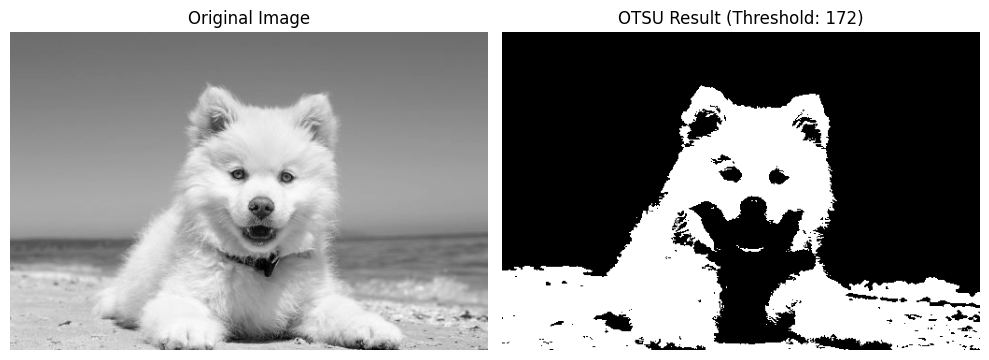

In [7]:
def transition(threshold, image):  # 返回二值化后的图像数据
    print(f"最佳阈值: {threshold}")
    # 逻辑是: < threshold 为 0, >= threshold 为 255。
    # 注意：cv2.threshold 返回两个值 (ret, dst)，我们需要第二个
    ret, binary_img = cv2.threshold(image, threshold, 255, cv2.THRESH_BINARY)

    return binary_img


# 1. 读取图像 (使用 cv2)
file_path = './imgs/examples/2.jpg' 
# cv2.IMREAD_GRAYSCALE (或者 0) 直接以灰度模式读取
gray = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)

# 2. 初始化遗传算法
# 种群数量设为 16
ga = GA(gray, 16)
print("种群迭代中...")
# 3. 迭代进化
for x in range(10):  # 迭代50次通常对简单二值化足够了
    ga.evolution()
    if x % 10 == 0:
        print(f"Generation {x}: Current Population: {ga.species}")

# 4. 获取最佳阈值
max_threshold = ga.get_threshold()
print("最终计算的最佳阈值为：", max_threshold)

# 5. 获取处理后的图像
result_image = transition(max_threshold, gray)

plt.figure(figsize=(10, 5))
# 原图
plt.subplot(1, 2, 1)
plt.imshow(gray, cmap='gray')
plt.title('Original Image')
plt.axis('off')

# 处理后的图
plt.subplot(1, 2, 2)
plt.imshow(result_image, cmap='gray')
plt.title(f'OTSU Result (Threshold: {max_threshold})')
plt.axis('off')

plt.tight_layout()
plt.show()